C:\Users\fishb\AppData\Local\Temp\ipykernel_3672\2623307423.py:366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\fishb\AppData\Local\Temp\ipykernel_3672\2623307423.py:366: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


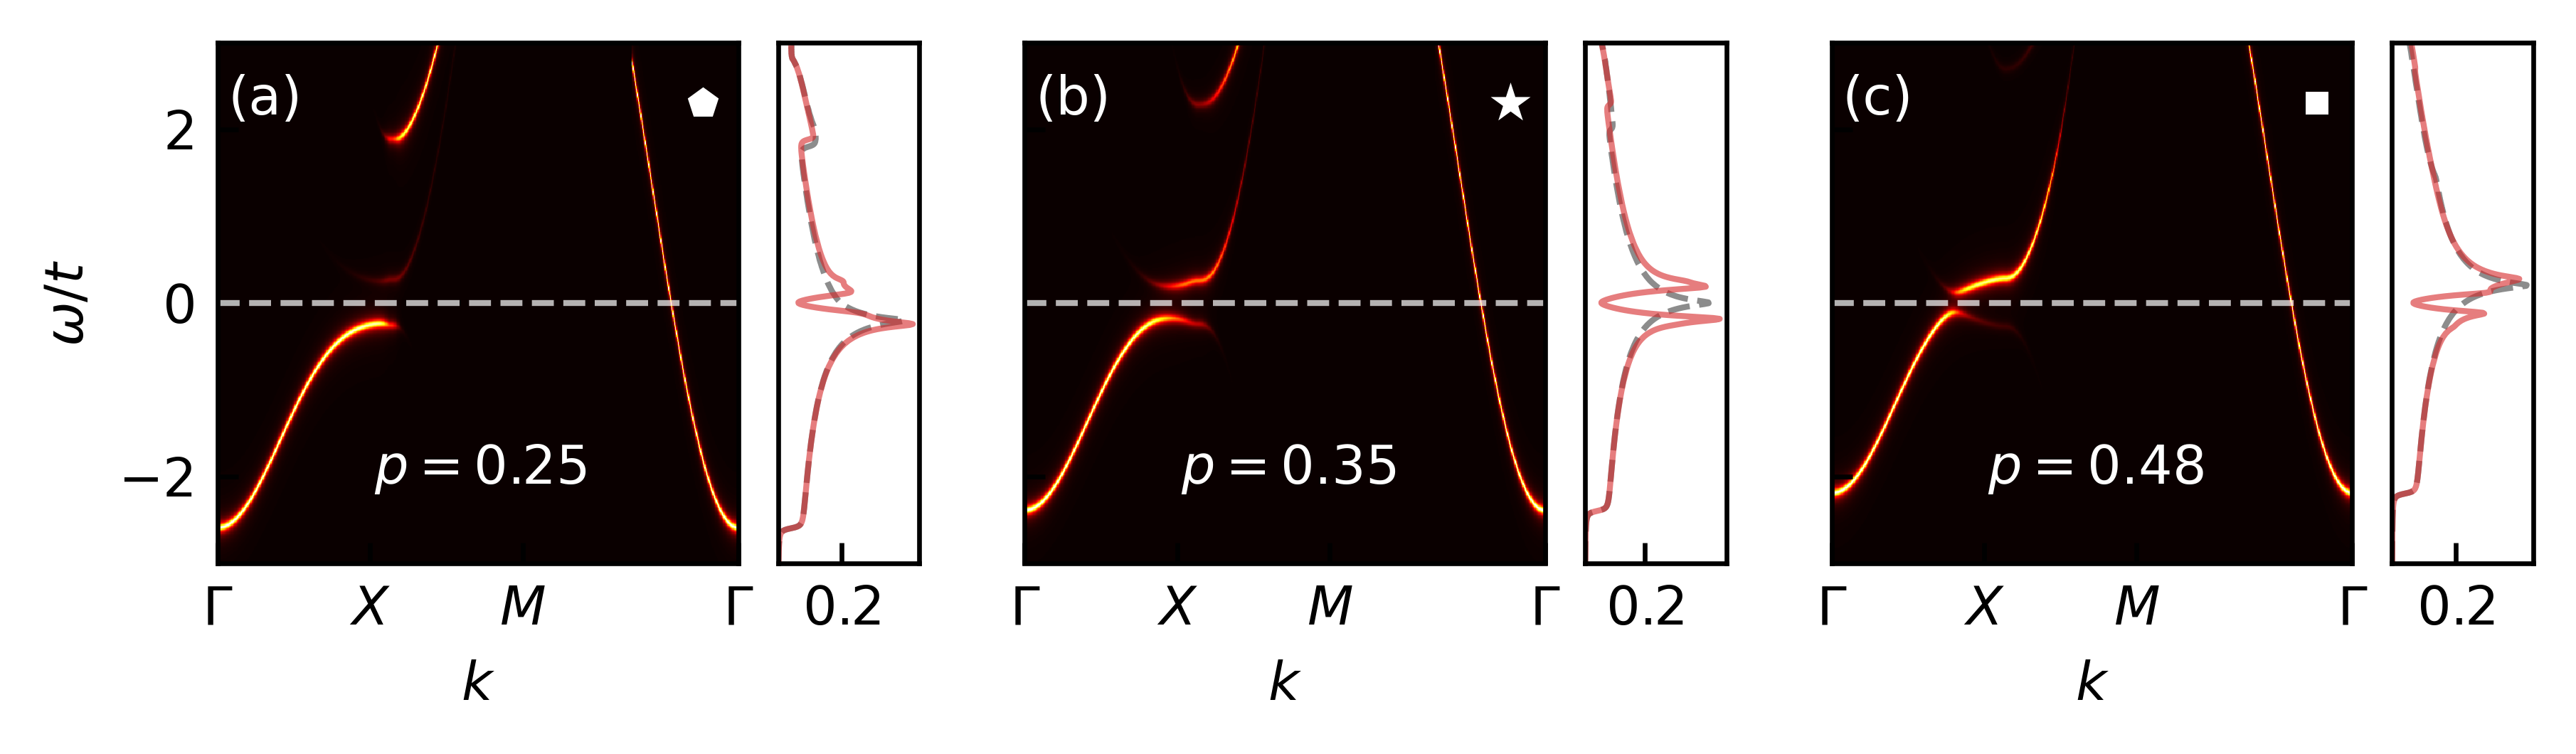

Saved PDF: C:\Users\fishb\Desktop\2025Fermi arc superconducting\code\fig5-sc_spectrum\fermi_arc_spectrum_dos.pdf
Elapsed time: 1.15 s


In [33]:
from pathlib import Path
import os
import time

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.labelsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
    }
)


def value_strings(value):
    """Try both compact and default float string formats for saved filenames."""
    return list(dict.fromkeys([str(value), f"{value:g}"]))


def first_existing_path(paths):
    for path in paths:
        if path.exists():
            return path
    candidates = "\n".join(str(path) for path in paths)
    raise FileNotFoundError(f"None of these files exists:\n{candidates}")


def spectrum_filename(data_dir, U, mu, J):
    paths = []
    for U_str in value_strings(U):
        for mu_str in value_strings(mu):
            for J_str in value_strings(J):
                paths.append(data_dir / f"sc_spectrum_U={U_str}_mu={mu_str}J={J_str}.npy")
    return first_existing_path(paths)


def dos_filename(data_dir, state, U, mu, J, nk_dos, gamma):
    paths = []
    for U_str in value_strings(U):
        for mu_str in value_strings(mu):
            for J_str in value_strings(J):
                for gamma_str in value_strings(gamma):
                    tag = f"U={U_str}_mu={mu_str}_J={J_str}_nkdos={nk_dos}_gamma={gamma_str}"
                    paths.append(data_dir / f"{state}_dos_{tag}.npy")
    return first_existing_path(paths)


def load_dos_pair(data_dir, U, mu, J, nk_dos, gamma):
    normal_path = dos_filename(data_dir, "normal", U, mu, J, nk_dos, gamma)
    sc_path = dos_filename(data_dir, "sc", U, mu, J, nk_dos, gamma)

    normal_dos = np.load(normal_path)
    sc_dos = np.load(sc_path)

    if normal_dos.shape != sc_dos.shape:
        raise ValueError(
            f"Shape mismatch for mu={mu}: "
            f"normal_dos.shape={normal_dos.shape}, sc_dos.shape={sc_dos.shape}"
        )

    return normal_dos, sc_dos


def k_path_gamma_x_m_gamma(numk):
    gamma_pt = np.array([0.0, 0.0])
    x_pt = np.array([np.pi, 0.0])
    m_pt = np.array([np.pi, np.pi])

    k_gx = np.linspace(gamma_pt, x_pt, numk, endpoint=False, axis=1)
    k_xm = np.linspace(x_pt, m_pt, numk, endpoint=False, axis=1)
    k_mg = np.linspace(m_pt, gamma_pt, numk + 1, axis=1)
    kpath = np.hstack((k_gx, k_xm, k_mg))

    klen = np.zeros(kpath.shape[1])
    for i in range(1, klen.size):
        klen[i] = klen[i - 1] + np.linalg.norm(kpath[:, i] - kpath[:, i - 1])

    xticks = [
        0.0,
        np.linalg.norm(x_pt - gamma_pt),
        np.linalg.norm(x_pt - gamma_pt) + np.linalg.norm(m_pt - x_pt),
        klen[-1],
    ]
    xlabels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

    return klen, xticks, xlabels


def band(kx, ky):
    return (
        -2.0 * t * (np.cos(kx) + np.cos(ky))
        - 4.0 * t1 * np.cos(kx) * np.cos(ky)
        - 2.0 * t2 * (np.cos(2.0 * kx) + np.cos(2.0 * ky))
    )


def band_Q(kx, ky):
    return (
        -2.0 * t * (np.cos(kx + Q[0]) + np.cos(ky + Q[1]))
        - 4.0 * t1 * np.cos(kx + Q[0]) * np.cos(ky + Q[1])
        - 2.0 * t2 * (
            np.cos(2.0 * (kx + Q[0])) + np.cos(2.0 * (ky + Q[1]))
        )
    )


def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu

    if T < 1e-8:
        T = 1e-8

    beta_T = 1.0 / T

    E_0 = np.zeros_like(epsilon_minus_mu)
    E_1 = -beta_T * epsilon_Q_minus_mu
    E_2 = -beta_T * (epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta_T * epsilon_minus_mu

    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])

    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = (
        np.exp(E_0 - E_max)
        + np.exp(E_1 - E_max)
        + np.exp(E_2 - E_max)
        + np.exp(E_3 - E_max)
    )

    return numerator / denominator


def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0 * np.sum(n_k) / N


# -------------------------- user parameters --------------------------
t = 1.0
t1 = -0.2
t2 = 0.1
Q = [np.pi, np.pi]

U = 2
J = 0.8
nk_dos = 256
gamma = 0.02

mu_values = [-1.0, -1.2, -1.4]

# These must match the spectrum/DOS generation scripts.
omega_min = -3.0
omega_max = 3.0

spectrum_xlim = None
dos_xlim = None
omega_ylim = (-3.0, 3.0)

cmap = "hot"
# cmap = "magma_r"
# cmap = "magma"
# cmap = "OrRd"
# cmap = "Reds"
# cmap = "gnuplot"
# cmap = 'Greys'
output_pdf = data_dir / "fermi_arc_spectrum_dos.pdf"
output_png = data_dir / "fermi_arc_spectrum_dos.png"

save_pdf = True
save_png = True

T_density = 1e-4 * J
Nk_density = 256

marker_styles = [
    dict(s=30, marker="p", facecolors="white", edgecolors="black", linewidths=0.0, zorder=4),
    dict(s=50, marker="*", color="white", linewidths=0.0, zorder=4, alpha=1.0),
    dict(s=15, marker="s", facecolors="white", edgecolors="black", linewidths=0.0, zorder=4),
]


# -------------------------- load data --------------------------
spectra = []
normal_dos_list = []
sc_dos_list = []

for mu in mu_values:
    spectra.append(np.load(spectrum_filename(data_dir, U, mu, J)))
    normal_dos, sc_dos = load_dos_pair(
        data_dir=data_dir,
        U=U,
        mu=mu,
        J=J,
        nk_dos=nk_dos,
        gamma=gamma,
    )
    normal_dos_list.append(normal_dos)
    sc_dos_list.append(sc_dos)

numomega_spectrum, numk_total = spectra[0].shape
numomega_dos = normal_dos_list[0].shape[0]

if numomega_spectrum != numomega_dos:
    raise ValueError(
        f"Spectrum and DOS use different omega-grid lengths: "
        f"{numomega_spectrum} vs {numomega_dos}."
    )

numk = (numk_total - 1) // 3
klen, xticks, xlabels = k_path_gamma_x_m_gamma(numk)
omegas = np.linspace(omega_min, omega_max, numomega_spectrum)

spectrum_extent = [klen[0], klen[-1], omega_min, omega_max]

kx_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N_density = Nk_density * Nk_density
doping_values = [
    1.0 - average_occupation(mu, T_density, U, KX, KY, N_density)
    for mu in mu_values
]


# -------------------------- plot --------------------------
start_time = time.time()

n_cols = len(mu_values)

fig = plt.figure(figsize=(7, 2.093), dpi=600)
outer_grid = fig.add_gridspec(
    1,
    n_cols,
    wspace=0.15,
)

panel_labels = [f"({chr(ord('a') + i)})" for i in range(n_cols)]
shared_y_axis = None

for col, (mu, spectrum_data, normal_dos, sc_dos, doping, panel_label) in enumerate(
    zip(mu_values, spectra, normal_dos_list, sc_dos_list, doping_values, panel_labels)
):
    inner_grid = outer_grid[0, col].subgridspec(
        1,
        2,
        width_ratios=[4.6, 1.25],
        wspace=0.12,
    )

    if shared_y_axis is None:
        ax_spec = fig.add_subplot(inner_grid[0, 0])
        shared_y_axis = ax_spec
    else:
        ax_spec = fig.add_subplot(inner_grid[0, 0], sharey=shared_y_axis)

    ax_dos = fig.add_subplot(inner_grid[0, 1], sharey=shared_y_axis)

    ax_spec.imshow(
        spectrum_data,
        origin="lower",
        aspect="auto",
        extent=spectrum_extent,
        cmap=cmap,
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0*np.max(spectrum_data),
    )
    ax_spec.set_box_aspect(1.0)
    ax_dos.set_box_aspect(4.6 / 1.25)

    ax_spec.axhline(
        0.0,
        color="white",
        linestyle="--",
        linewidth=1.0,
        alpha=0.7,
    )

    ax_spec.text(
        0.02,
        0.94,
        panel_label,
        transform=ax_spec.transAxes,
        color="white",
        ha="left",
        va="top",
    )

    ax_spec.text(
        0.3,
        0.18,
        rf"$p={doping:.2f}$",
        transform=ax_spec.transAxes,
        color="white",
        ha="left",
        va="center",
    )

    marker_style = marker_styles[col % len(marker_styles)]
    ax_spec.scatter(10.0, 2.3, **marker_style)

    ax_spec.set_xticks(xticks)
    ax_spec.set_xticklabels(xlabels)
    ax_spec.set_xlabel(r"$k$")

    if col == 0:
        ax_spec.set_ylabel(r"$\omega/t$")
    else:
        ax_spec.tick_params(axis="y", labelleft=False)

    if spectrum_xlim is not None:
        ax_spec.set_xlim(*spectrum_xlim)

    if omega_ylim is not None:
        ax_spec.set_ylim(*omega_ylim)

    ax_spec.set_yticks([-2.0, 0.0, 2.0])

    ax_dos.plot(
        normal_dos,
        omegas,
        "--",
        color="0.55",
        linewidth=1.0,
        label="normal",
    )
    ax_dos.plot(
        sc_dos,
        omegas,
        "-",
        color="C3",
        linewidth=1.0,
        label="SC",
        alpha=0.6,
    )


    if dos_xlim is not None:
        ax_dos.set_xlim(*dos_xlim)
    else:
        ax_dos.set_xlim(left=0.0)

    ax_dos.tick_params(axis="y", left=False, labelleft=False)
    # ax_dos.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_dos.set_xticks([0.2])
    ax_dos.set_xticklabels([r"$0.2$"])
    ax_dos.tick_params(direction="in")
    ax_spec.tick_params(direction="in")

fig.tight_layout()

if save_pdf:
    fig.savefig(output_pdf, bbox_inches="tight")

if save_png:
    fig.savefig(output_png, dpi=600, bbox_inches="tight")

# plt.close()
plt.show()

print(f"Saved PDF: {output_pdf}")
# print(f"Saved PNG: {output_png}")
print(f"Elapsed time: {time.time() - start_time:.2f} s")


In [32]:
from matplotlib import _cm

print(_cm._hot_data)

{'red': ((0.0, 0.0416, 0.0416), (0.365079, 1.0, 1.0), (1.0, 1.0, 1.0)), 'green': ((0.0, 0.0, 0.0), (0.365079, 0.0, 0.0), (0.746032, 1.0, 1.0), (1.0, 1.0, 1.0)), 'blue': ((0.0, 0.0, 0.0), (0.746032, 0.0, 0.0), (1.0, 1.0, 1.0))}


In [21]:
np.max(spectrum_data)

7.957743999771974

C:\Users\fishb\AppData\Local\Temp\ipykernel_3672\1750518426.py:390: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\fishb\AppData\Local\Temp\ipykernel_3672\1750518426.py:390: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


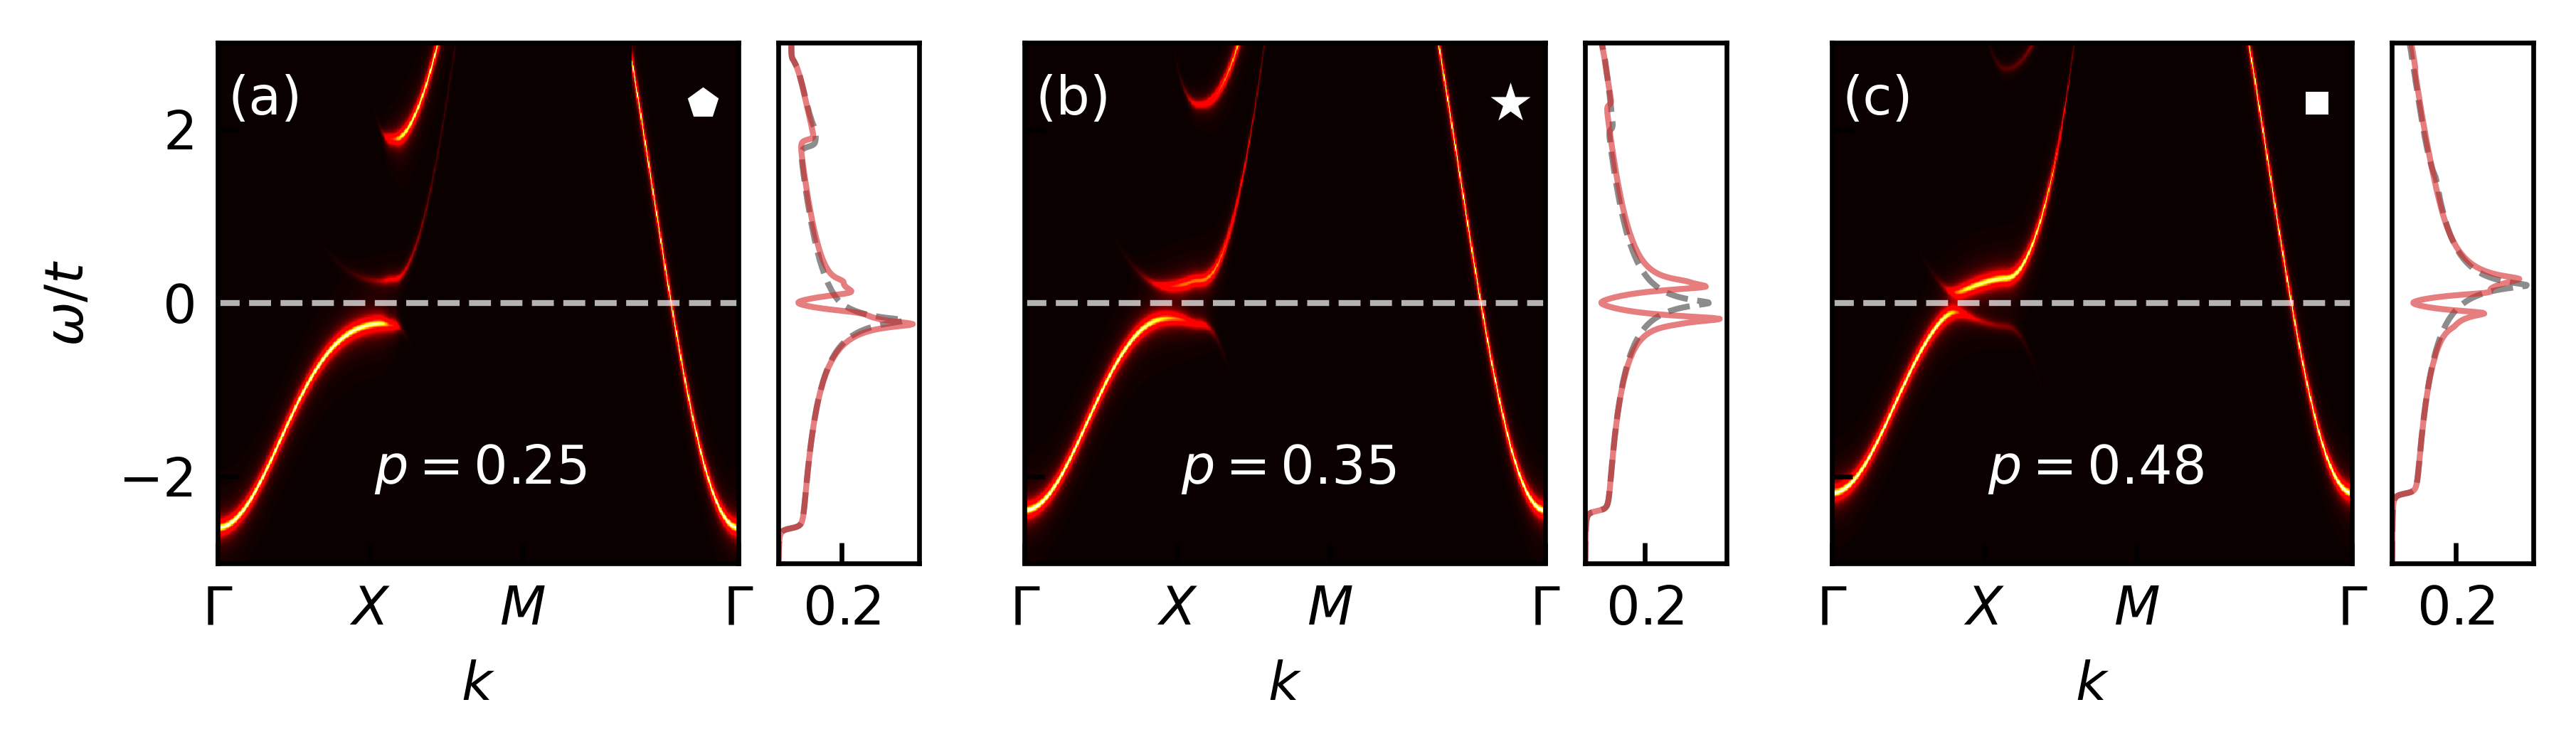

Saved PDF: C:\Users\fishb\Desktop\2025Fermi arc superconducting\code\fig5-sc_spectrum\fermi_arc_spectrum_dos.pdf
Elapsed time: 1.07 s


In [46]:
from pathlib import Path
import os
import time

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.labelsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
    }
)


def value_strings(value):
    """Try both compact and default float string formats for saved filenames."""
    return list(dict.fromkeys([str(value), f"{value:g}"]))


def first_existing_path(paths):
    for path in paths:
        if path.exists():
            return path
    candidates = "\n".join(str(path) for path in paths)
    raise FileNotFoundError(f"None of these files exists:\n{candidates}")


def spectrum_filename(data_dir, U, mu, J):
    paths = []
    for U_str in value_strings(U):
        for mu_str in value_strings(mu):
            for J_str in value_strings(J):
                paths.append(data_dir / f"sc_spectrum_U={U_str}_mu={mu_str}J={J_str}.npy")
    return first_existing_path(paths)


def dos_filename(data_dir, state, U, mu, J, nk_dos, gamma):
    paths = []
    for U_str in value_strings(U):
        for mu_str in value_strings(mu):
            for J_str in value_strings(J):
                for gamma_str in value_strings(gamma):
                    tag = f"U={U_str}_mu={mu_str}_J={J_str}_nkdos={nk_dos}_gamma={gamma_str}"
                    paths.append(data_dir / f"{state}_dos_{tag}.npy")
    return first_existing_path(paths)


def load_dos_pair(data_dir, U, mu, J, nk_dos, gamma):
    normal_path = dos_filename(data_dir, "normal", U, mu, J, nk_dos, gamma)
    sc_path = dos_filename(data_dir, "sc", U, mu, J, nk_dos, gamma)

    normal_dos = np.load(normal_path)
    sc_dos = np.load(sc_path)

    if normal_dos.shape != sc_dos.shape:
        raise ValueError(
            f"Shape mismatch for mu={mu}: "
            f"normal_dos.shape={normal_dos.shape}, sc_dos.shape={sc_dos.shape}"
        )

    return normal_dos, sc_dos


def k_path_gamma_x_m_gamma(numk):
    gamma_pt = np.array([0.0, 0.0])
    x_pt = np.array([np.pi, 0.0])
    m_pt = np.array([np.pi, np.pi])

    k_gx = np.linspace(gamma_pt, x_pt, numk, endpoint=False, axis=1)
    k_xm = np.linspace(x_pt, m_pt, numk, endpoint=False, axis=1)
    k_mg = np.linspace(m_pt, gamma_pt, numk + 1, axis=1)
    kpath = np.hstack((k_gx, k_xm, k_mg))

    klen = np.zeros(kpath.shape[1])
    for i in range(1, klen.size):
        klen[i] = klen[i - 1] + np.linalg.norm(kpath[:, i] - kpath[:, i - 1])

    xticks = [
        0.0,
        np.linalg.norm(x_pt - gamma_pt),
        np.linalg.norm(x_pt - gamma_pt) + np.linalg.norm(m_pt - x_pt),
        klen[-1],
    ]
    xlabels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

    return klen, xticks, xlabels


def band(kx, ky):
    return (
        -2.0 * t * (np.cos(kx) + np.cos(ky))
        - 4.0 * t1 * np.cos(kx) * np.cos(ky)
        - 2.0 * t2 * (np.cos(2.0 * kx) + np.cos(2.0 * ky))
    )


def band_Q(kx, ky):
    return (
        -2.0 * t * (np.cos(kx + Q[0]) + np.cos(ky + Q[1]))
        - 4.0 * t1 * np.cos(kx + Q[0]) * np.cos(ky + Q[1])
        - 2.0 * t2 * (
            np.cos(2.0 * (kx + Q[0])) + np.cos(2.0 * (ky + Q[1]))
        )
    )


def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu

    if T < 1e-8:
        T = 1e-8

    beta_T = 1.0 / T

    E_0 = np.zeros_like(epsilon_minus_mu)
    E_1 = -beta_T * epsilon_Q_minus_mu
    E_2 = -beta_T * (epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta_T * epsilon_minus_mu

    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])

    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = (
        np.exp(E_0 - E_max)
        + np.exp(E_1 - E_max)
        + np.exp(E_2 - E_max)
        + np.exp(E_3 - E_max)
    )

    return numerator / denominator


def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0 * np.sum(n_k) / N

hot_red_early = {
    "red": (
        (0.0, 0.0416, 0.0416),
        # (0.365079, 1.0, 1.0), 
        (0.15, 1.0, 1.0), 
        (1.0, 1.0, 1.0),
    ),
    "green": (
        (0.0, 0.0, 0.0),
        (0.365079, 0.0, 0.0),
        (0.746032, 1.0, 1.0),
        (1.0, 1.0, 1.0),
    ),
    "blue": (
        (0.0, 0.0, 0.0),
        (0.746032, 0.0, 0.0),
        (1.0, 1.0, 1.0),
    ),
}

my_hot = LinearSegmentedColormap("hot_red_early", hot_red_early)


# -------------------------- user parameters --------------------------
t = 1.0
t1 = -0.2
t2 = 0.1
Q = [np.pi, np.pi]

U = 2
J = 0.8
nk_dos = 256
gamma = 0.02

mu_values = [-1.0, -1.2, -1.4]

# These must match the spectrum/DOS generation scripts.
omega_min = -3.0
omega_max = 3.0

spectrum_xlim = None
dos_xlim = None
omega_ylim = (-3.0, 3.0)

# cmap = "hot"
cmap = my_hot
# cmap = "magma_r"
# cmap = "magma"
# cmap = "OrRd"
# cmap = "Reds"
# cmap = "gnuplot"
# cmap = 'Greys'
output_pdf = data_dir / "fermi_arc_spectrum_dos.pdf"
output_png = data_dir / "fermi_arc_spectrum_dos.png"

save_pdf = True
save_png = True

T_density = 1e-4 * J
Nk_density = 256

marker_styles = [
    dict(s=30, marker="p", facecolors="white", edgecolors="black", linewidths=0.0, zorder=4),
    dict(s=50, marker="*", color="white", linewidths=0.0, zorder=4, alpha=1.0),
    dict(s=15, marker="s", facecolors="white", edgecolors="black", linewidths=0.0, zorder=4),
]


# -------------------------- load data --------------------------
spectra = []
normal_dos_list = []
sc_dos_list = []

for mu in mu_values:
    spectra.append(np.load(spectrum_filename(data_dir, U, mu, J)))
    normal_dos, sc_dos = load_dos_pair(
        data_dir=data_dir,
        U=U,
        mu=mu,
        J=J,
        nk_dos=nk_dos,
        gamma=gamma,
    )
    normal_dos_list.append(normal_dos)
    sc_dos_list.append(sc_dos)

numomega_spectrum, numk_total = spectra[0].shape
numomega_dos = normal_dos_list[0].shape[0]

if numomega_spectrum != numomega_dos:
    raise ValueError(
        f"Spectrum and DOS use different omega-grid lengths: "
        f"{numomega_spectrum} vs {numomega_dos}."
    )

numk = (numk_total - 1) // 3
klen, xticks, xlabels = k_path_gamma_x_m_gamma(numk)
omegas = np.linspace(omega_min, omega_max, numomega_spectrum)

spectrum_extent = [klen[0], klen[-1], omega_min, omega_max]

kx_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N_density = Nk_density * Nk_density
doping_values = [
    1.0 - average_occupation(mu, T_density, U, KX, KY, N_density)
    for mu in mu_values
]


# -------------------------- plot --------------------------
start_time = time.time()

n_cols = len(mu_values)

fig = plt.figure(figsize=(7, 2.093), dpi=600)
outer_grid = fig.add_gridspec(
    1,
    n_cols,
    wspace=0.15,
)

panel_labels = [f"({chr(ord('a') + i)})" for i in range(n_cols)]
shared_y_axis = None

for col, (mu, spectrum_data, normal_dos, sc_dos, doping, panel_label) in enumerate(
    zip(mu_values, spectra, normal_dos_list, sc_dos_list, doping_values, panel_labels)
):
    inner_grid = outer_grid[0, col].subgridspec(
        1,
        2,
        width_ratios=[4.6, 1.25],
        wspace=0.12,
    )

    if shared_y_axis is None:
        ax_spec = fig.add_subplot(inner_grid[0, 0])
        shared_y_axis = ax_spec
    else:
        ax_spec = fig.add_subplot(inner_grid[0, 0], sharey=shared_y_axis)

    ax_dos = fig.add_subplot(inner_grid[0, 1], sharey=shared_y_axis)

    ax_spec.imshow(
        spectrum_data,
        origin="lower",
        aspect="auto",
        extent=spectrum_extent,
        cmap=cmap,
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0*np.max(spectrum_data),
    )
    ax_spec.set_box_aspect(1.0)
    ax_dos.set_box_aspect(4.6 / 1.25)

    ax_spec.axhline(
        0.0,
        color="white",
        linestyle="--",
        linewidth=1.0,
        alpha=0.7,
    )

    ax_spec.text(
        0.02,
        0.94,
        panel_label,
        transform=ax_spec.transAxes,
        color="white",
        ha="left",
        va="top",
    )

    ax_spec.text(
        0.3,
        0.18,
        rf"$p={doping:.2f}$",
        transform=ax_spec.transAxes,
        color="white",
        ha="left",
        va="center",
    )

    marker_style = marker_styles[col % len(marker_styles)]
    ax_spec.scatter(10.0, 2.3, **marker_style)

    ax_spec.set_xticks(xticks)
    ax_spec.set_xticklabels(xlabels)
    ax_spec.set_xlabel(r"$k$")

    if col == 0:
        ax_spec.set_ylabel(r"$\omega/t$")
    else:
        ax_spec.tick_params(axis="y", labelleft=False)

    if spectrum_xlim is not None:
        ax_spec.set_xlim(*spectrum_xlim)

    if omega_ylim is not None:
        ax_spec.set_ylim(*omega_ylim)

    ax_spec.set_yticks([-2.0, 0.0, 2.0])

    ax_dos.plot(
        normal_dos,
        omegas,
        "--",
        color="0.55",
        linewidth=1.0,
        label="normal",
    )
    ax_dos.plot(
        sc_dos,
        omegas,
        "-",
        color="C3",
        linewidth=1.0,
        label="SC",
        alpha=0.6,
    )


    if dos_xlim is not None:
        ax_dos.set_xlim(*dos_xlim)
    else:
        ax_dos.set_xlim(left=0.0)

    ax_dos.tick_params(axis="y", left=False, labelleft=False)
    # ax_dos.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_dos.set_xticks([0.2])
    ax_dos.set_xticklabels([r"$0.2$"])
    ax_dos.tick_params(direction="in")
    ax_spec.tick_params(direction="in")

fig.tight_layout()

if save_pdf:
    fig.savefig(output_pdf, bbox_inches="tight")

if save_png:
    fig.savefig(output_png, dpi=600, bbox_inches="tight")


# plt.close()
plt.show()

print(f"Saved PDF: {output_pdf}")
# print(f"Saved PNG: {output_png}")
print(f"Elapsed time: {time.time() - start_time:.2f} s")
